In [ ]:
from google.colab import files
upload=files.upload()

Saving iris.csv to iris (1).csv


In [ ]:
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn import tree
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline



In [ ]:
iris_df=pd.read_csv("iris(1).csv")
iris_df.head()



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris_df.isnull().any()
iris_df.dtypes
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

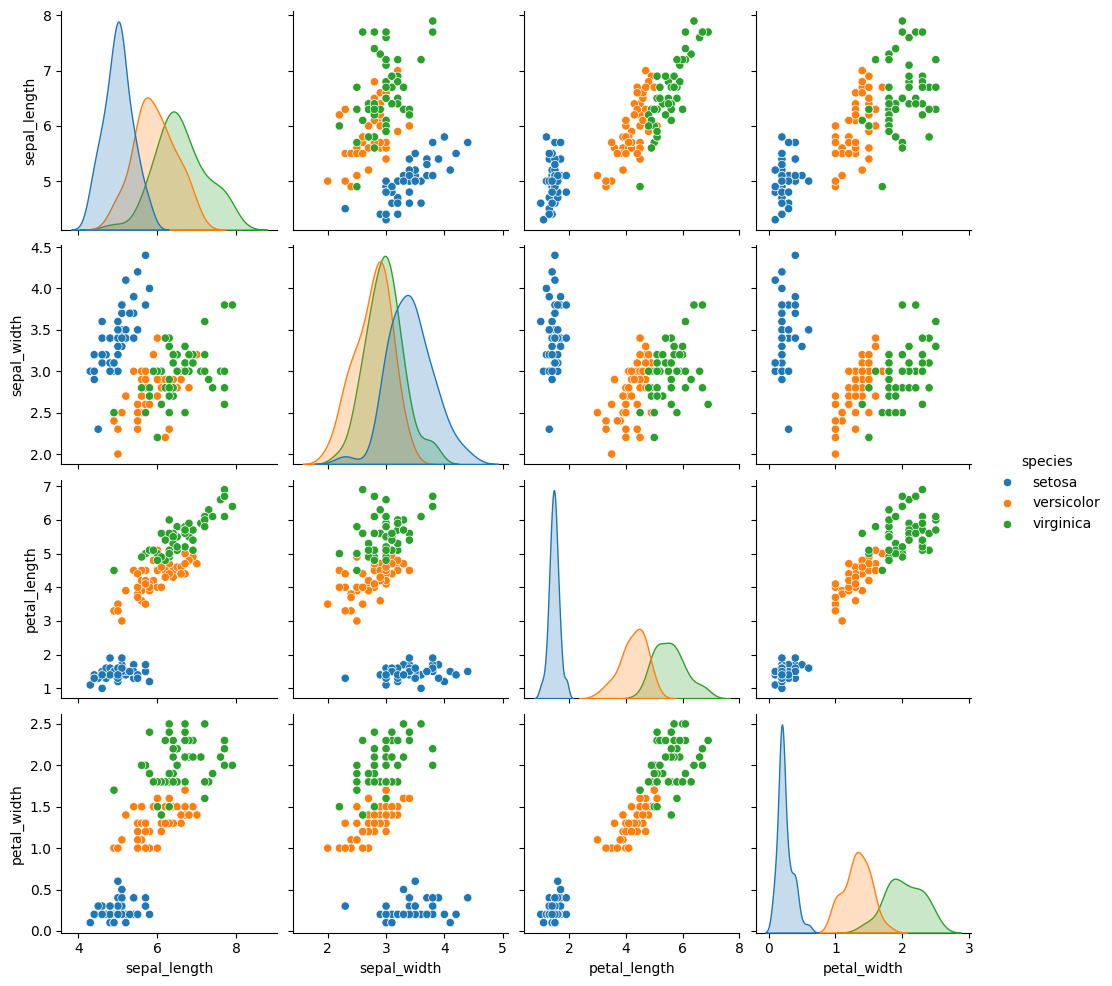

In [ ]:
sns.pairplot(iris_df,hue='species')
plt.savefig("exercise2a.png")
files.download("exercise2a.png")

In [ ]:
X= iris_df[['sepal_length','sepal_width','petal_length','petal_width']].values
y= iris_df['species'].values
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.9,random_state=1,stratify=y)
print(f"Training Shapes:{X_train.shape},{y_train.shape}")
print(f"Testing shapes:{X_test.shape},{y_test.shape}")

Training Shapes:(135, 4),(135,)
Testing shapes:(15, 4),(15,)


In [ ]:
clf=tree.DecisionTreeClassifier()
clf=clf.fit(X_train,y_train)

In [ ]:
prediction= clf.predict(X_test)
prediction


array(['versicolor', 'versicolor', 'virginica', 'setosa', 'versicolor',
       'setosa', 'setosa', 'virginica', 'versicolor', 'virginica',
       'setosa', 'versicolor', 'versicolor', 'virginica', 'setosa'],
      dtype=object)

In [ ]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       0.83      1.00      0.91         5
   virginica       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



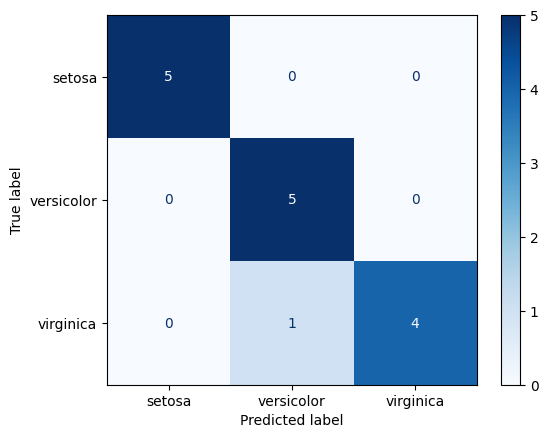

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from google.colab import files
import matplotlib.pyplot as plt
disp=ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test,cmap=plt.cm.Blues)
plt.savefig("excercise2b.png",bbox_inches='tight',dpi=300)
plt.show()
files.download("excercise2b.png")

In [ ]:
!pip install pydotplus
!apt-get update
!apt-get install -y graphviz

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,332 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:14 http:/

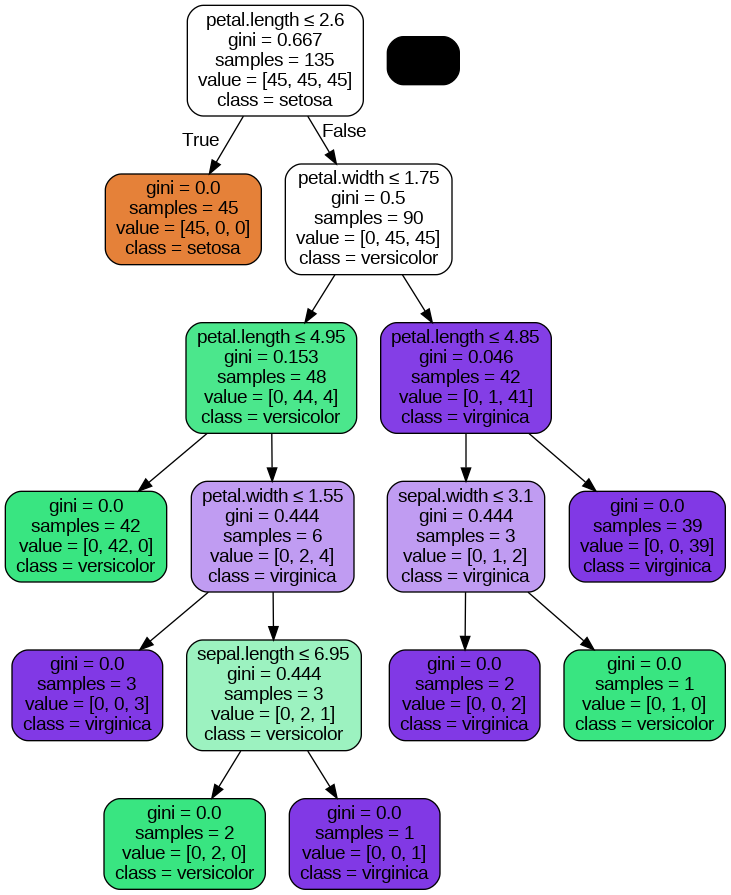

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from io import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
from google.colab import files
dot_data=StringIO()
export_graphviz(clf,out_file=dot_data,feature_names=['sepal.length','sepal.width','petal.length','petal.width'],class_names=clf.classes_.astype(str),filled=True,rounded=True,special_characters=True)
graph=pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png("excercise2c.png")
display(Image(graph.create_png()))
files.download("excercise2c.png")


In [ ]:
sepal_length=4.8
sepal_width=2.9
petal_length=1.3
petal_width=0.2
X=[[sepal_length,sepal_width,petal_length,petal_width]]
res=clf.predict(X)
print("The class predicted is->"+str(res[0]))

The class predicted is->setosa
